In [ ]:
MODEL_CLS = "bacf"
COMB = None
HIDDEN_DIM = (
    [128, 64, 32]
    if COMB=="cat"
    else [64, 32]
)
DATASET = "abeauty"
STRATEGY = "pointwise"
PATH_WORK_DIR = "../../.."

In [ ]:
if DATASET=="abeauty":
    NUM_USERS = 3819
    NUM_ITEMS = 1581
    FILTER = "default"
    MAX_LEN = None
elif DATASET=="amusic":
    NUM_USERS = 5541
    NUM_ITEMS = 3568
    FILTER = "default"
    MAX_LEN = None
elif DATASET=="lastfm":
    NUM_USERS = 1892
    NUM_ITEMS = 17632
    FILTER = "default"
    MAX_LEN = None
elif DATASET=="movielens":
    NUM_USERS = 610
    NUM_ITEMS = 9724
    FILTER = "tfidf"
    MAX_LEN = 400
else:
    raise ValueError()

ANCHOR = "user"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\RESEARCH\2025-2 MDPI\BACF


In [4]:
import sys
sys.path.append("src")

# Config

In [5]:
import pandas as pd
from components import histories
from pointwiseBayes import config, datamodule, trainer, evaluator, utils
import bacf

In [6]:
PATH = f"./config/{MODEL_CLS}_{STRATEGY}.yaml"
cfg = config.build(PATH)

In [7]:
utils.seed.main(cfg.seed)

ALL SEEDS RESET: 42


# Data Preparation

In [8]:
PATH = f"./data/{DATASET}.csv"
df = pd.read_csv(PATH)

In [9]:
kwargs = dict(
    df=df,
    percentile=0.9,
)

utils.desc.main(**kwargs)

number of user: 3819
number of item: 1581
total interaction: 34278
interaction density: 0.5677 %
max interaction of user: 127
max interaction of item: 1221
top 10.0 % interaction of user: 15.0
top 10.0 % interaction of item: 30.0
mean interaction of user: 8
mean interaction of item: 21


In [10]:
kwargs = dict(
    df=df,
    cfg=cfg.datamodule,
)

dataloaders, trn = datamodule.build(**kwargs)

In [ ]:
kwargs = dict(
    df=trn,
    num_users=NUM_USERS,
    num_items=NUM_ITEMS,
    anchor=ANCHOR,
    filter=FILTER,
    max_len=MAX_LEN,
)

histories_cls = histories.Histories(**kwargs)

# Modeling

In [ ]:
kwargs = dict(
    histories=histories_cls,
    num_users=NUM_USERS,
    num_items=NUM_ITEMS,
    hidden_dim=HIDDEN_DIM,
    comb=COMB,
    **cfg.model.params,
)

model = bacf.bacf.BayesianAttentionalCollaborativeFiltering(**kwargs)

# Train

In [13]:
kwargs = dict(
    model=model,
    cfg=cfg.trainer,
)

opt = trainer.build(**kwargs)

In [14]:
kwargs = dict(
    trn_loader=dataloaders["trn"],
    val_loader=dataloaders["val"],
)

records = opt.fit(**kwargs)

BEST EPOCH: 34
BEST SCORE: 0.6765


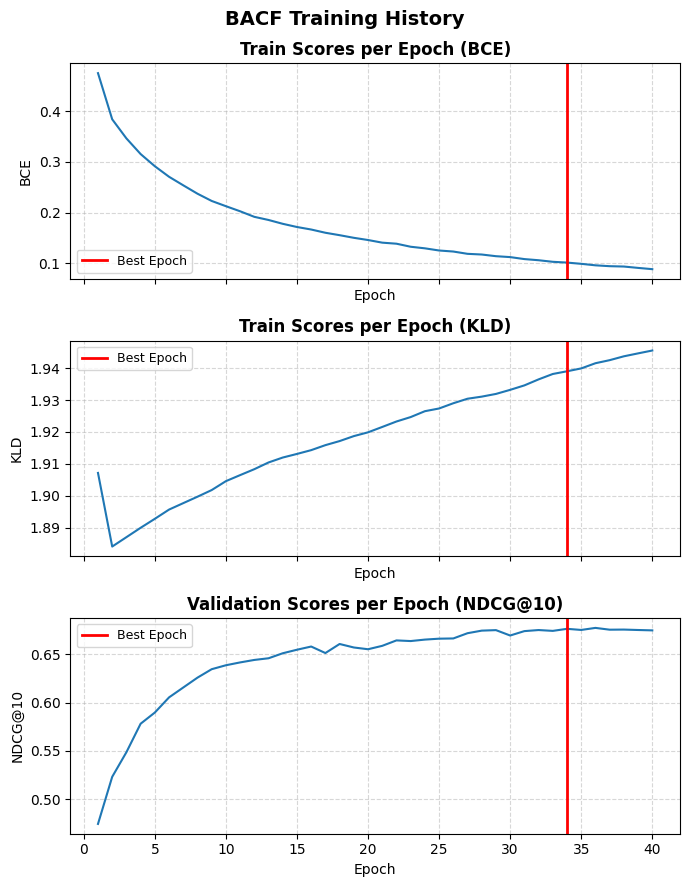

In [15]:
kwargs = dict(
    records=records,
    suptitle="BACF Training History",
    trn="BCE",
    val="NDCG@10",
    figsize=(7,3),
)

utils.visualizer.main(**kwargs)

# Test

In [16]:
kwargs = dict(
    model=model,
    cutoff=[5,10,15,20,25,50],
)

msr = evaluator.build(**kwargs)

In [20]:
result, metrics_sheet = msr(dataloaders["tst"])

TST: 100%|██████████| 438/438 [00:03<00:00, 116.53it/s]


In [18]:
metrics_sheet

,k,hit_ratio,precision,recall,map,ndcg
0,5,0.610601,0.160220,0.608079,0.655308,0.575740
1,10,0.676725,0.103359,0.682198,0.814068,0.595776
2,15,0.723957,0.077250,0.735203,0.885985,0.608575
3,20,0.769877,0.060496,0.780841,0.888683,0.619628
4,25,0.805038,0.049971,0.814690,0.890255,0.627288
5,50,0.932826,0.028082,0.946595,0.894360,0.653647


# Save

In [ ]:
PATH = f'./checkpoints/{DATASET}/{MODEL_CLS}/{COMB}_{STRATEGY}.pth'

kwargs = dict(
    obj=model,
    path=PATH,
)

utils.checkpointer.save(**kwargs)